# Init

In [3]:
import torch

# DTYPE = torch.float16
DTYPE = torch.float32

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

from diffusers import AutoencoderKL

vae32 = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="vae"    
).to(device)  

Using device: cuda


In [4]:
import numpy as np
import torch.nn.functional as F

def resize_crop_latent(image: torch.Tensor, K: np.ndarray, patch_size: int = 32, vae_scale=8):
    """
    Resize/crop a latent tensor (C,H,W) or (1,C,H,W) with subpixel accuracy.
    """
    if image.ndim == 3:
        image = image.unsqueeze(0)  # (1,C,H,W)

    _, _, h, w = image.shape
    scale = patch_size / min(h, w)
    new_w, new_h = w * scale, h * scale
    crop_x = (new_w - patch_size) / 2
    crop_y = (new_h - patch_size) / 2

    # Affine transform normalized to [-1,1]
    M = np.array([[scale, 0, -crop_x],
                  [0, scale, -crop_y]], dtype=np.float32)
    theta = torch.tensor(M, dtype=torch.float32, device=image.device).unsqueeze(0)
    grid = F.affine_grid(theta, size=(1, image.shape[1], patch_size, patch_size), align_corners=False)
    cropped_resized = F.grid_sample(image, grid, mode='bilinear', align_corners=False)

    # Adjust K for scale/crop and latent scale
    K_scaled = K.copy()
    K_scaled[:2, :] *= scale / vae_scale
    K_scaled[0, 2] -= crop_x / vae_scale
    K_scaled[1, 2] -= crop_y / vae_scale

    return cropped_resized.squeeze(0), K_scaled

In [5]:
import torch
import matplotlib.pyplot as plt

def show_tensor(tensor, title=None):
    """
    Display a single image tensor using matplotlib.
    Works for:
      - [3, H, W] RGB tensors
      - [1, H, W] grayscale tensors
      - [B, 3, H, W] -> shows the first image in the batch

    Args:
        tensor (torch.Tensor): Image tensor to display.
        title (str, optional): Optional title for the plot.
    """
    # Move to CPU and detach from graph
    tensor = tensor.detach().cpu()

    # Handle batch dimension
    if tensor.dim() == 4:
        tensor = tensor[0]

    # If normalized to [-1, 1], convert back to [0, 1]
    if tensor.min() < 0:
        tensor = (tensor + 1) / 2

    # Clamp to [0, 1] just in case
    tensor = tensor.clamp(0, 1)

    # Convert from (C, H, W) → (H, W, C)
    if tensor.shape[0] == 3:
        img = tensor.permute(1, 2, 0).numpy()
        plt.imshow(img)
    elif tensor.shape[0] == 1:
        img = tensor.squeeze(0).numpy()
        plt.imshow(img, cmap="gray")
    else:
        raise ValueError(f"Unsupported tensor shape: {tensor.shape}")

    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [6]:
# from dataset.py - removed K-related stuff
from typing import Tuple
import cv2

def resize_crop_with_subpixel_accuracy(
    image: np.ndarray, patch_size: int
) -> np.ndarray:
    """Resize and crop the image to have the smallest side equal to `patch_size`,
    while maintaining sub-pixel accuracy using a single warpAffine transformation.

    Args:
        image (np.ndarray): Input image.
        K (np.ndarray): Camera intrinsic matrix.
        patch_size (int): Target size of the smaller dimension.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Resized and cropped image, updated intrinsic matrix.
    """
    h, w = image.shape[:2]
    scale = patch_size / min(h, w)

    # Compute the affine transformation matrix combining scaling and cropping
    new_w, new_h = w * scale, h * scale
    crop_x = (new_w - patch_size) / 2
    crop_y = (new_h - patch_size) / 2

    M = np.array([[scale, 0, -crop_x], [0, scale, -crop_y]], dtype=np.float32)

    # Apply affine transformation with sub-pixel accuracy
    is_downsampling = min(h, w) > patch_size
    interpolation = cv2.INTER_AREA if is_downsampling else cv2.INTER_CUBIC
    cropped_resized_image = cv2.warpAffine(
        image, M, (patch_size, patch_size), flags=interpolation
    )
    

    return cropped_resized_image

# Load Data
## Load Tensor

/tmp/ipykernel_224276/3924692404.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_pre = torch.load(tensor_path)


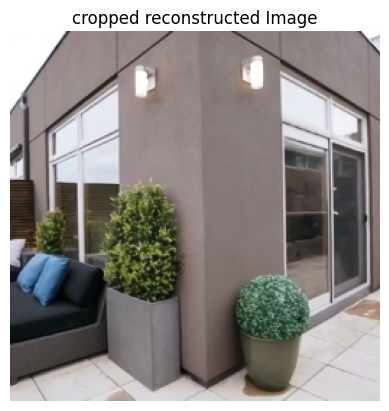

tensor([[[[0.9986, 1.0132, 1.0057,  ..., 0.9824, 0.9997, 1.0127],
          [0.9954, 1.0119, 0.9914,  ..., 0.9884, 0.9724, 1.0028],
          [1.0048, 0.9981, 0.9975,  ..., 0.9595, 0.9615, 0.8918],
          ...,
          [0.6765, 0.6684, 0.6652,  ..., 0.6775, 0.6803, 0.6817],
          [0.6893, 0.6833, 0.6717,  ..., 0.6751, 0.6767, 0.6703],
          [0.6935, 0.6885, 0.6901,  ..., 0.6713, 0.6754, 0.6631]],

         [[1.0262, 1.0032, 0.9998,  ..., 0.9885, 0.9836, 0.9653],
          [1.0050, 1.0031, 1.0017,  ..., 1.0017, 0.9699, 0.9770],
          [1.0005, 0.9909, 0.9998,  ..., 0.9669, 0.9363, 0.8761],
          ...,
          [0.6346, 0.6463, 0.6433,  ..., 0.6593, 0.6603, 0.6607],
          [0.6495, 0.6506, 0.6545,  ..., 0.6516, 0.6526, 0.6517],
          [0.6600, 0.6512, 0.6632,  ..., 0.6491, 0.6535, 0.6404]],

         [[0.9903, 1.0067, 1.0106,  ..., 0.9824, 0.9976, 0.9849],
          [1.0042, 0.9905, 1.0011,  ..., 0.9948, 0.9983, 1.0238],
          [1.0012, 0.9994, 1.0076,  ..., 0

In [17]:
# load tensor 
tensor_path = f"../data_processed/realestate10k_latent/train/0c6c060f599465ed/images/59959900.pt"
image_pre = torch.load(tensor_path)
K = np.eye(3)
image, K = resize_crop_latent(image_pre, K)

image = image.permute(1, 2, 0) # [C,W,H] → [W,H,C]
image = image.permute(2, 0, 1).unsqueeze(0).to(device) # [W,H,C] → [1,C,W,H]            
# image.shape     = torch.Size([1, 16, 32, 32])

with torch.no_grad():        
    image_reconstructed = vae32.decode(image.float()).sample

show_tensor(image_reconstructed.float(), title="cropped reconstructed Image")

image_reconstructed.cpu()

## Load Pixel

In [18]:
import imageio.v2 as imageio

img_path = f"../data_processed/realestate10k/train/0c6c060f599465ed/images/59959900.png"
image = imageio.imread(img_path)[..., :3]

image = resize_crop_with_subpixel_accuracy(image, 256)

image = torch.Tensor(image)
image = image.permute(2,0,1) / 255


# Compare

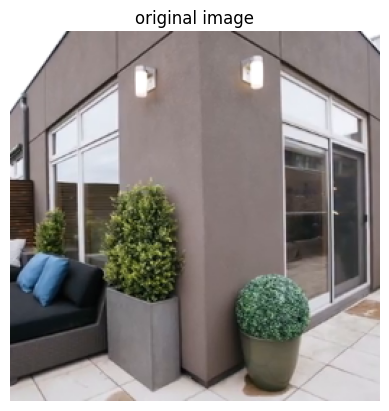

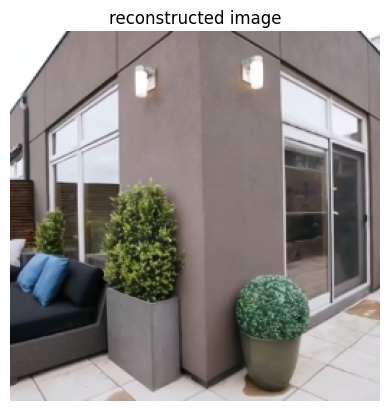

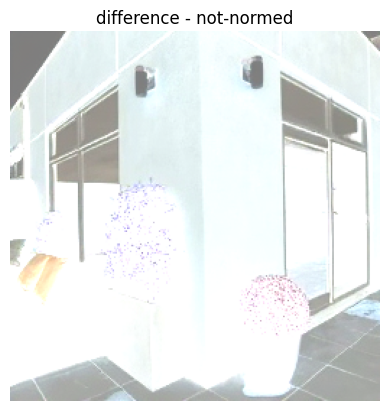

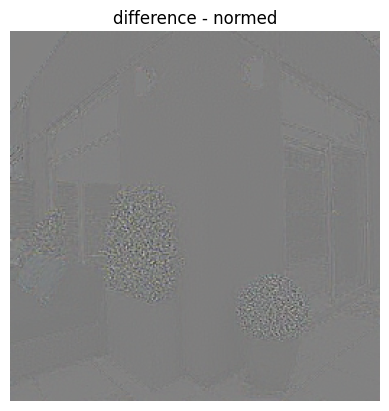

mse_avg (normed): 0.0005891905748285353


In [19]:
import torch.nn.functional as F

# print(image)

# print(image_reconstructed)

show_tensor(image.float(), title="original image")
show_tensor(image_reconstructed.float(), title="reconstructed image")
diff = (image.cpu() - image_reconstructed.cpu()) + 0.5
show_tensor(diff.float(), title="difference - not-normed")


def norm(x):
    return (x - x.min()) / (x.max() - x.min())

image_normed = norm(image)
reconstructed_normed = norm(image_reconstructed)

diff_normed = image_normed.cpu() - reconstructed_normed.cpu() + 0.5

show_tensor(diff_normed.float(), title="difference - normed")

mse = F.mse_loss(image_normed.cpu(), reconstructed_normed.squeeze().cpu())
print(f"mse_avg (normed): {mse}")